                                      drug_abuse  major_crime  public_crime  \
drug_abuse                                  1.00         0.57          0.74   
major_crime                                 0.57         1.00          0.56   
public_crime                                0.74         0.56          1.00   
violent_crime                               0.81         0.81          0.88   
perceived_neighborhood_violence_rate        0.40         0.20          0.62   
perceived_neighborhood_safety_rate         -0.32        -0.04         -0.56   
trust_in_law_enforcement                    0.25         0.67          0.14   
trust_in_law_enforcement_rate              -0.22        -0.26         -0.44   
trust_in_local_government                   0.22         0.63          0.13   
trust_in_local_government_rate             -0.29        -0.24         -0.50   
economic_diversity_index                    0.04        -0.42          0.21   
hardship_index                              0.20    

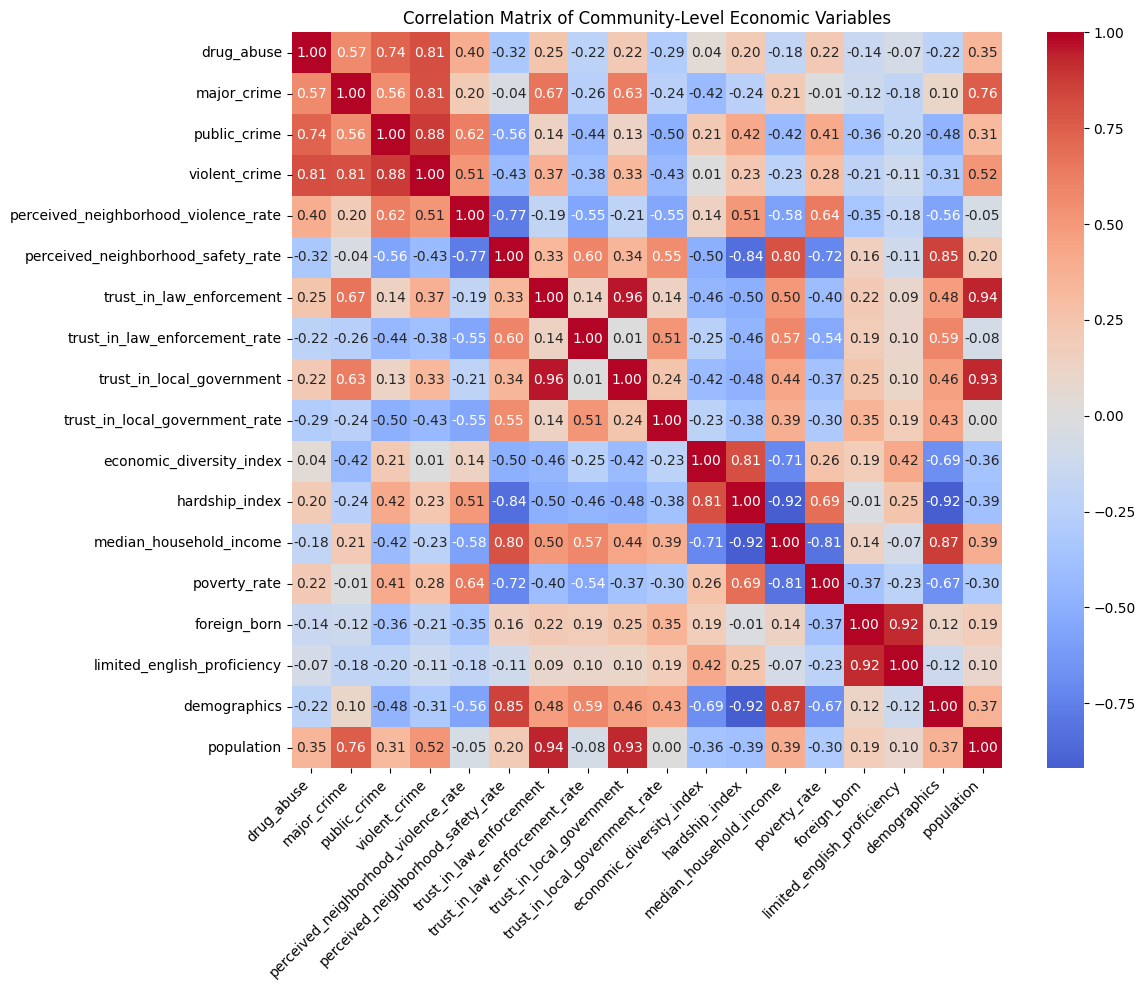

In [5]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("community_area_data.csv")

# economic variables we want to examine
econ_vars = [
    "drug_abuse",
    "major_crime",
    "public_crime",
    "violent_crime",
    "perceived_neighborhood_violence_rate",
    "perceived_neighborhood_safety_rate",
    "trust_in_law_enforcement",
    "trust_in_law_enforcement_rate",
    "trust_in_local_government",
    "trust_in_local_government_rate",
    "economic_diversity_index",
    "hardship_index",
    "median_household_income",
    "poverty_rate",
    "foreign_born",
    "limited_english_proficiency",
    "demographics",
    "population"
]

# subset for the variables we want
community_only = df[["community_area_id"] + econ_vars]

# correlation matrix
corr_matrix = community_only[econ_vars].corr()

# print rounded version
print(corr_matrix.round(2))

# plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Community-Level Economic Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


keep these columns

* violent_crime
* perceived_neighborhood_safety_rate
* trust_in_law_enforcement_rate
* economic_diversity_index
* median_household_income
* limited_english_proficiency
* population   (control)

                                    perceived_neighborhood_safety_rate  \
perceived_neighborhood_safety_rate                                1.00   
trust_in_law_enforcement_rate                                     0.60   
economic_diversity_index                                         -0.50   
median_household_income                                           0.80   
limited_english_proficiency                                      -0.11   
population                                                        0.20   

                                    trust_in_law_enforcement_rate  \
perceived_neighborhood_safety_rate                           0.60   
trust_in_law_enforcement_rate                                1.00   
economic_diversity_index                                    -0.25   
median_household_income                                      0.57   
limited_english_proficiency                                  0.10   
population                                                  -0.08  

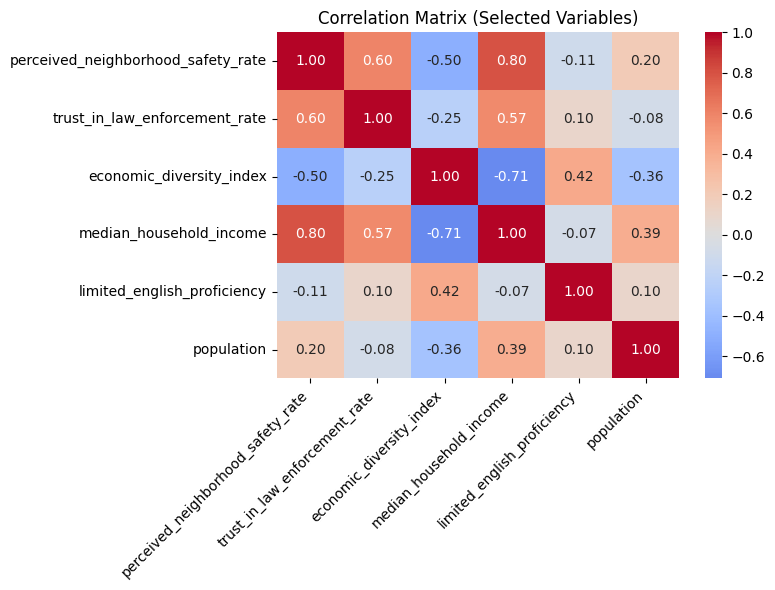

In [6]:
final_vars = [
    #"violent_crime", (not very interpretable)
    "perceived_neighborhood_safety_rate",
    "trust_in_law_enforcement_rate",
    "economic_diversity_index",
    "median_household_income",
    "limited_english_proficiency",
    "population",
    #"poverty_rate" (remove because too highly correlated)
    ]

community_only = df[
    ["community_area_id"] + final_vars
].drop_duplicates(subset="community_area_id")

corr_matrix_clean = community_only[final_vars].corr()

print(corr_matrix_clean.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Selected Variables)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

